## 1. Imports and Hardware Setup

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm

In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print(f"Using device: {DEVICE}")

In [2]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_PATH = './data'
    SAVE_PATH = '/content/drive/MyDrive/DL'
    print("✅ Contected to Google Drive")
except(ValueError, ImportError, Exception) as e:
    print(f"❌ Error: {e}")
    print("❌ Failed to mount to Google Drive --> ✅ Use Local Path")
    DATA_PATH = "./data"
    SAVE_PATH = DATA_PATH

Mounted at /content/drive
✅ Contected to Google Drive


## 2. Hyperparameters

In [3]:
BATCH_SIZE = 64
LEARNING_RATE = 0.001
EPOCHS = 10

Using device: cuda


## 3. Dataset Preparation

MNIST images are 28x28. LeNet-5 was originally trained on 32x32 images, so we resize them and normalize.

In [4]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(root=DATA_PATH, train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root=DATA_PATH, train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 16.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 432kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.99MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.2MB/s]


## 4. LeNet-5 Model Architecture

The architecture consists of:
1. **C1 (Convolutional)**: 6 filters, 5x5 kernel, stride 1. Input: 32x32x1 -> Output: 28x28x6.
2. **S2 (Average Pooling)**: 2x2 kernel, stride 2. Output: 14x14x6.
3. **C3 (Convolutional)**: 16 filters, 5x5 kernel. Output: 10x10x16.
4. **S4 (Average Pooling)**: 2x2 kernel, stride 2. Output: 5x5x16.
5. **C5 (Convolutional)**: 120 filters, 5x5 kernel. Output: 1x1x120.
6. **F6 (Fully Connected)**: 84 units.
7. **Output (Fully Connected)**: 10 units (for digits 0-9).

In [ ]:
class LeNet5(nn.Module):
    def __init__(self, num_classes=10):
        super(LeNet5, self).__init__()
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(1, 6, kernel_size=5),
            nn.Tanh(),
            nn.AvgPool2d(kernel_size=2, stride=2),
            nn.Conv2d(6, 16, kernel_size=5),
            nn.Tanh(),
            nn.AvgPool2d(kernel_size=2, stride=2),
            nn.Conv2d(16, 120, kernel_size=5),
            nn.Tanh()
        )
        
        self.classifier = nn.Sequential(
            nn.Linear(120, 84),
            nn.Tanh(),
            nn.Linear(84, num_classes)
        )

    def forward(self, x):
        x = self.feature_extractor(x)
        x = torch.flatten(x, 1)
        logits = self.classifier(x)
        return logits

model = LeNet5().to(DEVICE)
print(model)

LeNet5(
  (feature_extractor): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
    (1): Tanh()
    (2): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (4): Tanh()
    (5): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (6): Conv2d(16, 120, kernel_size=(5, 5), stride=(1, 1))
    (7): Tanh()
  )
  (classifier): Sequential(
    (0): Linear(in_features=120, out_features=84, bias=True)
    (1): Tanh()
    (2): Linear(in_features=84, out_features=10, bias=True)
  )
)


## 5. Training Loop

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    
    for images, labels in tqdm(loader, desc="Training", leave=False):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        
    return running_loss / len(loader.dataset), correct / len(loader.dataset)

def validate_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validating", leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            
    return running_loss / len(loader.dataset), correct / len(loader.dataset)

history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, DEVICE)
    test_loss, test_acc = validate_epoch(model, test_loader, criterion, DEVICE)
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)
    
    print(f"Epoch [{epoch+1}/{EPOCHS}] - "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

Training:   0%|          | 0/938 [00:00<?, ?it/s]

Validating:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [1/10] - Train Loss: 0.2389, Train Acc: 0.9332 | Test Loss: 0.0821, Test Acc: 0.9752


Training:   0%|          | 0/938 [00:00<?, ?it/s]

Validating:   0%|          | 0/157 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [9/10] - Train Loss: 0.0153, Train Acc: 0.9950 | Test Loss: 0.0414, Test Acc: 0.9871


Training:   0%|          | 0/938 [00:00<?, ?it/s]

Validating:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [10/10] - Train Loss: 0.0142, Train Acc: 0.9950 | Test Loss: 0.0394, Test Acc: 0.9886


## 6. Results Visualization

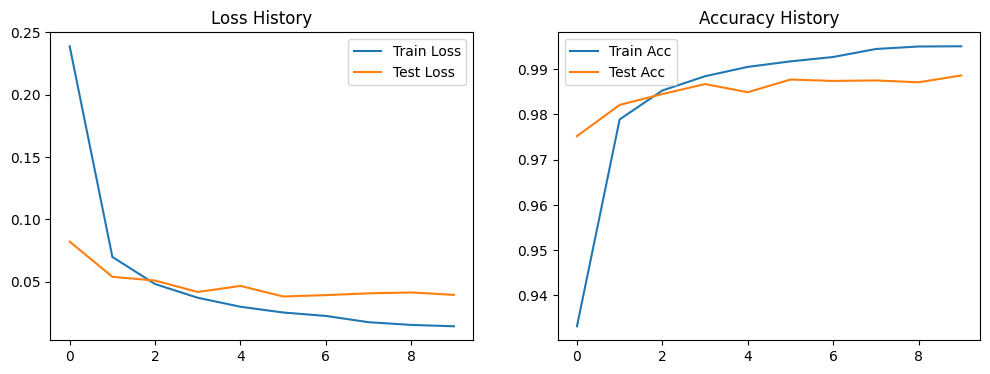

In [7]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['test_loss'], label='Test Loss')
plt.title('Loss History')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['test_acc'], label='Test Acc')
plt.title('Accuracy History')
plt.legend()
plt.show()

## 7. Model Inference Demo

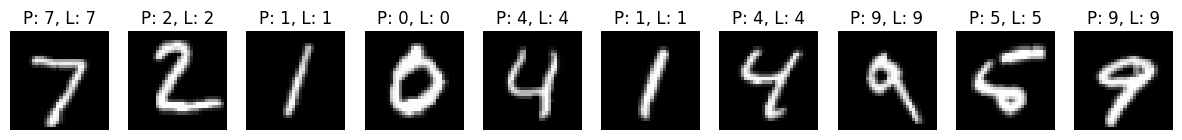

In [8]:
def visualize_inference(model, loader, device, num_images=10):
    model.eval()
    images, labels = next(iter(loader))
    images, labels = images.to(device), labels.to(device)
    outputs = model(images)
    _, preds = torch.max(outputs, 1)
    
    plt.figure(figsize=(15, 3))
    for i in range(num_images):
        plt.subplot(1, num_images, i+1)
        plt.imshow(images[i].cpu().squeeze(), cmap='gray')
        plt.title(f"P: {preds[i].item()}, L: {labels[i].item()}")
        plt.axis('off')
    plt.show()

visualize_inference(model, test_loader, DEVICE)